###Alphafold2 Conformation Generation Pipeline
Notebook and code written by Felipe Engelberger, 2024.
Built using ColabDesign by Sergey O.

felipeengelberger@gmail.com

In [ ]:
%%time
#%pip uninstall chex -y
# @title setup {"display-mode":"form"}
%pip -qq install git+https://github.com/sokrypton/ColabDesign.git@gamma
# @title Install
%cd /content
%pip install -q biopython igraph leidenalg
%pip -q install git+https://github.com/engelberger/frustrapy.git@dev
%pip install -q -U kaleido==0.2.1
%cd /workspaces/alphamask/
%pip install -e .

INFO:alphamask.utils.logging:Starting masking experiment with strategy: iterative_single


INFO:alphamask.utils.logging:Starting vanilla AlphaFold2 prediction (Control)


Setup path is present.
HHsuite is present.
mmseqs2 is imported.
jobname I89_vanilla_897a1_5
length=[94] copies=1
{'sequence': ['GSHMASMEDLQAEARAFLSEEMIAEFKAAFDMFDADGGGDISYKAVGTVFRMLGINPSKEVLDYLKEKIDVDGSGTIDFEEFLVLMVYIMKQDA'], 'copies': 1, 'msa_method': 'mmseqs2', 'pair_mode': 'unpaired_paired', 'do_not_filter': False, 'cov': 75, 'id': 90, 'template_mode': 'none', 'propagate_to_copies': True}
getting unpaired MSA


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:06 remaining: 00:00]


parsing msas
gathering info
filtering sequences
Current PATH: /bin:/root/.local/bin:/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/content/setup/hhsuite/bin:/content/setup/hhsuite/scripts
hhfilter location: /content/setup/hhsuite/bin/hhfilter
selecting final sequences


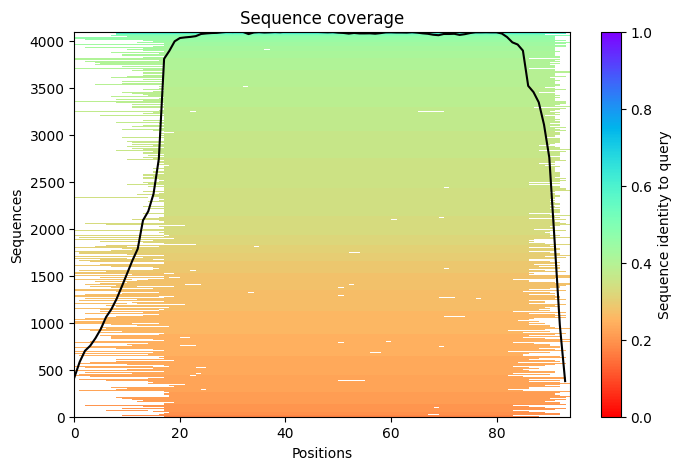

GC 11830
loading alphafold params
running prediction
seed=000 model=model_1_ptm recycle=0
seed=000 model=model_1_ptm recycle=1
seed=000 model=model_1_ptm recycle=2
seed=000 model=model_2_ptm recycle=0
seed=000 model=model_2_ptm recycle=1
seed=000 model=model_2_ptm recycle=2
seed=000 model=model_3_ptm recycle=0
seed=000 model=model_3_ptm recycle=1
seed=000 model=model_3_ptm recycle=2
seed=000 model=model_4_ptm recycle=0
seed=000 model=model_4_ptm recycle=1
seed=000 model=model_4_ptm recycle=2
seed=000 model=model_5_ptm recycle=0
seed=000 model=model_5_ptm recycle=1
seed=000 model=model_5_ptm recycle=2
best_tag=model_3_ptm_r2_seed_000 seed=000 model=model_3_ptm recycle=2 plddt=0.836 ptm=0.739 rmsd_tol=0.134
GC 20


INFO:alphamask.utils.logging:Vanilla AlphaFold2 prediction completed


INFO:alphamask.utils.logging:Vanilla results stored in: /content/I89_vanilla_897a1_5/out/pdbs


INFO:alphamask.utils.logging:Clearing memory


INFO:alphamask.utils.logging:Garbage collection: 2243 objects collected


INFO:alphamask.utils.logging:Experiment completed in 0:00:55.924933



🎯 Control Results Complete


In [6]:
# @markdown # Generalized AlphaFold2 Masking Experiment

# @markdown This script provides a flexible framework for running iterative masking experiments with AlphaFold2.
# @markdown By default, it performs single-position masking across your sequence. You can either:
# @markdown - Let it iterate through the entire sequence automatically
# @markdown - Provide a specific list of positions to iterate through
# @markdown - Alternatively, use traditional masked/unmasked position lists
# @markdown See the FAQ section at the bottom of this notebook for detailed usage examples.

from alphamask.utils import run_masking_experiment
from alphamask.core.msa import MSAUtils
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# @markdown ## Visualization Options
show_msa_plots = True  # @param {type:"boolean"}
show_coevolution = True  # @param {type:"boolean"}
plot_window = 10  # @param {type:"slider", min:5, max:50, step:5}

# @markdown ## Input Parameters

# @markdown **Input Sequence**
sequence = "GSHMASMEDLQAEARAFLSEEMIAEFKAAFDMFDADGGGDISYKAVGTVFRMLGINPSKEVLDYLKEKIDVDGSGTIDFEEFLVLMVYIMKQDA"  # @param {type:"string"}

# @markdown **Job Name Prefix**
jobname_prefix = "I89"  # @param {type:"string"}

# @markdown **Masking Strategy** (see FAQ for detailed explanation)
masking_strategy = "iterative_single"  # @param ["iterative_single","iterative_single_mask_mutate", "mask_positions", "unmask_positions"]

# @markdown **Positions to Process** (leave empty for full sequence in iterative mode, or enter comma-separated positions)
positions_str = ""  # @param {type:"string"}

# @markdown **Parent Path** (directory where results will be saved)
parent_path = "/content"  # @param {type:"string"}

# @markdown **AlphaFold2 Parameters**
num_recycles = 2  # @param {type:"slider", min:1, max:20, step:1}
num_seeds = 1  # @param {type:"slider", min:1, max:20, step:1}

# @markdown **MSA Method**
msa_method = "mmseqs2"  # @param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]

# @markdown **Custom a3m path** (leave empty for upload dialog, ignored for mmseqs2)
custom_a3m_path = "/here/your_aln.a3m"  # @param {type:"string"}

# @markdown **Run Control (Vanilla AF2)**
run_control = True  # @param {type:"boolean"}

# @markdown **Run Only Control**
run_only_control = True  # @param {type:"boolean"}

# @markdown **Mutations to Process** (leave empty for full sequence in iterative mode, or enter comma-separated positions)
mutations = ""  # @param {type:"string"}

# @markdown **Use Unified Memory**
unified_memory = False  # @param {type:"boolean"}

def visualize_experiment_results(pipeline, mutation_str=None):
    """Visualize MSA and coevolution results"""
    try:
        print("\n🔍 Accessing stored MSAs...")
        msas = pipeline.get_stored_msas()
        
        # Debug information
        print("\nAvailable MSA types:", list(msas.keys()))
        print("MSA values present:", {k: v is not None for k, v in msas.items()})
        
        msa_utils = MSAUtils()
        
        if msas['original'] is None:
            print("⚠️ Warning: No original MSA found!")
            return
            
        print(f"\nOriginal MSA shape: {msas['original'].shape}")
        
        if show_msa_plots:
            print("\n📊 MSA Visualizations")
            print("-" * 50)
            
            try:
                # Plot original MSA
                msa_utils.plot_2d_array(
                    array=msas['original'],
                    title="Original MSA",
                    xaxis_title="Position",
                    yaxis_title="Sequence",
                    save_to_pdf=f"{parent_path}/{pipeline.jobname}/original_msa.pdf"
                )
                
                if msas['mutated'] is not None:
                    print(f"Mutated MSA shape: {msas['mutated'].shape}")
                    # Plot mutated MSA
                    msa_utils.plot_2d_array(
                        array=msas['mutated'],
                        title="Mutated MSA",
                        xaxis_title="Position",
                        yaxis_title="Sequence",
                        save_to_pdf=f"{parent_path}/{pipeline.jobname}/mutated_msa.pdf"
                    )
                
                if msas['masked'] is not None:
                    print(f"Masked MSA shape: {msas['masked'].shape}")
                    # Plot masked MSA
                    msa_utils.plot_2d_array(
                        array=msas['masked'],
                        title="Masked MSA",
                        xaxis_title="Position",
                        yaxis_title="Sequence",
                        save_to_pdf=f"{parent_path}/{pipeline.jobname}/masked_msa.pdf"
                    )
            except Exception as e:
                print(f"⚠️ Error during MSA plotting: {str(e)}")

        if show_coevolution:
            print("\n🔄 Coevolution Analysis")
            print("-" * 50)
            
            try:
                # Calculate coevolution matrices
                coev_original = msa_utils.get_coevolution(msas['original'])
                print(f"Original coevolution matrix shape: {coev_original.shape}")
                
                fig = make_subplots(
                    rows=1, cols=3 if msas['masked'] is not None else 1,
                    subplot_titles=("Original Coevolution", "Mutated Coevolution", "Masked Coevolution")
                    if msas['masked'] is not None else ("Original Coevolution",)
                )
                
                # Add original coevolution
                fig.add_trace(
                    go.Heatmap(z=coev_original, colorscale='Viridis', name="Original"),
                    row=1, col=1
                )
                
                if msas['mutated'] is not None:
                    coev_mutated = msa_utils.get_coevolution(msas['mutated'])
                    print(f"Mutated coevolution matrix shape: {coev_mutated.shape}")
                    fig.add_trace(
                        go.Heatmap(z=coev_mutated, colorscale='Viridis', name="Mutated"),
                        row=1, col=2
                    )
                
                if msas['masked'] is not None:
                    coev_masked = msa_utils.get_coevolution(msas['masked'])
                    print(f"Masked coevolution matrix shape: {coev_masked.shape}")
                    fig.add_trace(
                        go.Heatmap(z=coev_masked, colorscale='Viridis', name="Masked"),
                        row=1, col=3
                    )
                
                # Update layout
                fig.update_layout(
                    title="Coevolution Analysis" + (f" - {mutation_str}" if mutation_str else ""),
                    height=500,
                    width=1500 if msas['masked'] is not None else 500,
                    showlegend=True
                )
                
                # Save and display
                fig.write_html(f"{parent_path}/{pipeline.jobname}/coevolution.html")
                fig.show()
            except Exception as e:
                print(f"⚠️ Error during coevolution analysis: {str(e)}")
        
        # Print statistics
        print("\n📈 MSA Statistics:")
        print(f"Total sequences: {msas['original'].shape[0]}")
        print(f"Sequence length: {msas['original'].shape[1]}")
        if mutation_str:
            print(f"Mutation: {mutation_str}")
            
    except Exception as e:
        print(f"❌ Error in visualization: {str(e)}")
        import traceback
        traceback.print_exc()

# Run the experiment
vanilla_control_jobname, vanilla_control_pipeline = run_masking_experiment(
    sequence=sequence,
    jobname_prefix=jobname_prefix,
    parent_path=parent_path,
    masking_strategy=masking_strategy,
    positions_str=positions_str,
    num_recycles=num_recycles,
    num_seeds=num_seeds,
    msa_method=msa_method,
    custom_a3m_path=custom_a3m_path,
    mutations=mutations,
    run_control=run_control,
    run_only_control=run_only_control,
    unified_memory=unified_memory,
    callback_fn=visualize_experiment_results
)

# No need for additional visualization since callback handles it
if vanilla_control_pipeline:
    print("\n🎯 Control Results Complete")

# Configurational Frustration

In [ ]:
%load_ext autoreload
%autoreload 2

from os.path import exists, join
import os
import glob
import shutil
import sys
import frustrapy


# @title Frustratometer in Python {"display-mode":"form"}
mode = "configurational" # @param ["configurational", "singleresidue", "mutational"]
overwrite = True # @param {type:"boolean"}
debug = "INFO" # @param ["INFO","DEBUG"]


results_dir = f"/content/{vanilla_control_jobname}/{mode}"
pdbs_dir = f"{results_dir}/best_pdb/"

# First, check if source files exist
source_files = glob.glob(f"/content/{vanilla_control_jobname}/out/pdbs/*best*")
if not source_files:
    raise FileNotFoundError(f"No files matching '*best*' pattern found in /content/{vanilla_control_jobname}/out/pdbs/")

# If overwrite is True, clear the results directory before creating new directories
if overwrite and exists(results_dir):
    os.system(f"rm -rf {results_dir}/*")

# Create the pdbs_dir
os.makedirs(pdbs_dir, exist_ok=True)

# Copy the best PDB file
assert len(source_files) == 1, f"Expected 1 best PDB file, found {len(source_files)}"
source_pdb = source_files[0]
pdb_file = os.path.basename(source_pdb)
destination_path = join(pdbs_dir, pdb_file)
shutil.copy(source_pdb, destination_path)

# Verify the file was copied correctly
if not exists(destination_path):
    raise FileNotFoundError(f"Failed to copy PDB file to {destination_path}")

# Now calculate frustration for the specific PDB file
try:
    pdb_config, plots_config, density_results, _ = frustrapy.calculate_frustration(
        pdb_file=destination_path,
        mode=mode,
        results_dir=results_dir,
        debug=debug.upper(),
        chain="A",
    )
    print("Frustration calculation completed successfully")
    print(f"Results saved in: {results_dir}")

except Exception as e:
    print(f"Error during frustration calculation: {str(e)}")
    # Print more detailed debugging information
    print(f"PDB file path: {destination_path}")
    print(f"PDB file exists: {exists(destination_path)}")
    print(f"Results directory exists: {exists(results_dir)}")
    raise

# You can add code here to work with the results
# pdb_config contains the PDB configuration
# plots_config contains the plotting configuration
# density_results contains the density calculation results

In [ ]:
# @title Select Figure to Display 📊 {"run":"auto","display-mode":"form"}
from IPython.display import clear_output
import plotly.io as pio
pio.renderers.default = 'vscode'

figure_name = "plot_5andens" # @param ["plot_5andens", "plot_5adens_proportions", "plot_contact_map"] {allow-input: true}

# Clear previous output
clear_output(wait=True)

# Display selected figure
if figure_name in plots_config:
    print(f"Displaying: {figure_name}")
    plots_config[figure_name].show()
else:
    print(f"Figure '{figure_name}' not found in plots_config!")
    print(f"Available figures: {list(plots_config.keys())}")

In [ ]:
# @title View Frustration Data 📊 {"run": "auto", "display-mode":"form"}
from IPython.display import clear_output
from google.colab import data_table
import pandas as pd

# Enable interactive data table formatting
data_table.enable_dataframe_formatter()

# Create filtering options
show_residue_range = True  # @param {type:"boolean"}
min_residue = 1  # @param {type:"slider", min:1, max:500, step:1}
max_residue = 94  # @param {type:"slider", min:1, max:500, step:1}
sort_by = "Rel_Minimally_Frustrated"  # @param ["Residue", "Total_Density", "Highly_Frustrated", "Neutrally_Frustrated", "Minimally_Frustrated", "Rel_Highly_Frustrated", "Rel_Neutrally_Frustrated", "Rel_Minimally_Frustrated"]
ascending = False  # @param {type:"boolean"}
rows_per_page = "50"  # @param [5, 10, 15, 20, 50, 100]

# Clear previous output
clear_output(wait=True)

# Create a list of dictionaries from the density results
data = []
for density in density_results.densities:
    data.append({
        'Residue': density.residue_number,
        'Chain': density.chain_id,
        'Total_Density': density.total_density,
        'Highly_Frustrated': density.highly_frustrated,
        'Neutrally_Frustrated': density.neutrally_frustrated,
        'Minimally_Frustrated': density.minimally_frustrated,
        'Rel_Highly_Frustrated': f"{density.rel_highly_frustrated:.2%}",
        'Rel_Neutrally_Frustrated': f"{density.rel_neutrally_frustrated:.2%}",
        'Rel_Minimally_Frustrated': f"{density.rel_minimally_frustrated:.2%}"
    })

# Create DataFrame
df = pd.DataFrame(data)

# Apply residue range filter if enabled
if show_residue_range:
    df = df[(df['Residue'] >= min_residue) & (df['Residue'] <= max_residue)]

# Sort the dataframe
if sort_by in ['Rel_Highly_Frustrated', 'Rel_Neutrally_Frustrated', 'Rel_Minimally_Frustrated']:
    # Convert percentage strings to floats for sorting
    sort_values = df[sort_by].str.rstrip('%').astype(float)
    df = df.iloc[sort_values.argsort()[::-1 if not ascending else 1]]
else:
    df = df.sort_values(by=sort_by, ascending=ascending)

# Print summary statistics
print(f"Showing {len(df)} residues")
if show_residue_range:
    print(f"Filtered for residues {min_residue}-{max_residue}")
print(f"Sorted by {sort_by} ({'ascending' if ascending else 'descending'})")
print("\nSummary Statistics:")
print(f"Average Total Density: {df['Total_Density'].mean():.2f}")
print(f"Average Minimally Frustrated: {df['Minimally_Frustrated'].mean():.2f}")

# Display interactive table
data_table.DataTable(df,
                    include_index=False,
                    num_rows_per_page=rows_per_page)


In [ ]:
# @title Single Residue Analysis for Top N Residues from Selected Range 🧬 {"run": "auto", "display-mode":"form"}
from IPython.display import clear_output
import pandas as pd
import os
from collections import defaultdict

# Amino acid conversion dictionaries
THREE_TO_ONE = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E',
    'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N',
    'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S',
    'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}

# Parameters
n_top_residues = 10  # @param {type:"slider", min:1, max:20, step:1}
mode = "singleresidue"  # @param ["singleresidue", "mutational"]
debug = "INFO"  # @param ["INFO", "DEBUG"]

# Clear previous output
clear_output(wait=True)

# Get the top N residues from the previously filtered and sorted DataFrame (df)
top_n = df.head(n_top_residues)

print(f"Analyzing top {n_top_residues} residues from range {min_residue}-{max_residue}:")
print(f"(Sorted by {sort_by} {'ascending' if ascending else 'descending'})")
print("\nSelected residues:")
print(top_n[['Residue', 'Chain', sort_by]].to_string(index=False))

# Prepare residues for analysis
residues_to_analyze = defaultdict(list)
for _, row in top_n.iterrows():
    residues_to_analyze[row['Chain']].append(int(row['Residue']))

# Convert defaultdict to regular dict for frustrapy
residues_to_analyze = dict(residues_to_analyze)

print(f"\nPreparing to analyze residues: {residues_to_analyze}")

# Calculate total mutations to process
total_mutations = sum(len(residues) for residues in residues_to_analyze.values()) * 20

print(f"\nTotal mutations to analyze: {total_mutations}")

try:
    # Find the PDB file in the pdbs_dir
    pdb_files = [f for f in os.listdir(pdbs_dir) if f.endswith('.pdb')]
    if not pdb_files:
        raise FileNotFoundError(f"No PDB files found in {pdbs_dir}")
    pdb_file = pdb_files[0]

    print(f"\nUsing PDB file: {pdb_file}")

    # Calculate frustration for single residues
    pdb_config, plots_config, density_results, single_residue_data = frustrapy.calculate_frustration(
        pdb_file=os.path.join(pdbs_dir, pdb_file),
        mode=mode,
        results_dir=results_dir,
        debug=debug.upper(),
        chain="A",
        residues=residues_to_analyze,
    )

    print("\nAnalysis completed successfully!")

    # Dictionary to store most frustrated mutations for each residue
    most_frustrated_mutations = {}

    # Analyze single residue data
    if single_residue_data and "A" in single_residue_data:
        print("\nMost Frustrated Mutations Analysis:")
        print("-" * 50)

        for res_num in residues_to_analyze["A"]:
            if res_num in single_residue_data["A"]:
                res_data = single_residue_data["A"][res_num]
                mutations = res_data.mutations

                # Convert three-letter code to one-letter code
                native_one_letter = THREE_TO_ONE.get(res_data.residue_name.upper(), 'X')

                # Find most frustrated mutation
                most_frustrated = min(mutations.items(), key=lambda x: x[1])

                # Store in dictionary
                most_frustrated_mutations[res_num] = {
                    'native': native_one_letter,
                    'mutation': most_frustrated[0],
                    'frustration_index': most_frustrated[1]
                }

                print(f"\nPosition {res_num} (Native: {native_one_letter} [from {res_data.residue_name}])")
                print(f"Most frustrated mutation: {native_one_letter} → {most_frustrated[0]} "
                      f"(Frustration Index: {most_frustrated[1]:.3f})")

                # Sort and display top 5 most frustrated mutations
                sorted_mutations = sorted(mutations.items(), key=lambda x: x[1])
                print("\nTop 5 most frustrated mutations:")
                for mut, score in sorted_mutations[:5]:
                    print(f"  {native_one_letter} → {mut}: {score:.3f}")

        print("\nMost Frustrated Mutations Summary:")
        print("-" * 50)
        for res_num, data in most_frustrated_mutations.items():
            mutation_str = f"{data['native']}{res_num}{data['mutation']}"
            print(f"Residue {res_num}: {mutation_str} (FI: {data['frustration_index']:.3f})")

    else:
        print("\nNo single residue data available in the results")

    # Display plots if available
    if plots_config:
        print("\nAvailable plots:")
        for plot_name, plot in plots_config.items():
            print(f"- {plot_name}")
            plot.show()

except Exception as e:
    print(f"Error during analysis: {str(e)}")
    print("\nDebug information:")
    print(f"Results directory: {results_dir}")
    print(f"PDBs directory: {pdbs_dir}")
    print(f"Residues to analyze: {residues_to_analyze}")
    raise

# Create DataFrame for interactive display
if 'most_frustrated_mutations' in locals():
    mutation_df = pd.DataFrame([
        {
            'Residue': res_num,
            'Native': data['native'],
            'Mutation': data['mutation'],
            'Mutation_String': f"{data['native']}{res_num}{data['mutation']}",
            'Frustration_Index': data['frustration_index']
        }
        for res_num, data in most_frustrated_mutations.items()
    ])



print("\nInteractive Mutations Table:")
data_table.DataTable(mutation_df, include_index=False, num_rows_per_page=20)


In [ ]:
%load_ext autoreload
%autoreload 2

from IPython.display import clear_output, display
import os
import gc
import jax
import pandas as pd
import numpy as np
from datetime import datetime
from alphamask.core import MutateAndMaskingPipeline

# Basic parameters
jobname_prefix = "I89"  # @param {type:"string"}
parent_path = "/content"  # @param {type:"string"}

# @markdown ### AlphaFold2 Configuration
num_recycles = 2  # @param {type:"slider", min:1, max:20, step:1}
num_seeds = 2  # @param {type:"slider", min:1, max:20, step:1}

# @markdown ### MSA Options
msa_method = "mmseqs2"  # @param ["mmseqs2", "single_sequence", "custom_fas", "custom_a3m", "custom_sto"] {type:"string"}
custom_a3m_path = ""  # @param {type:"string"}

def visualize_msa_region(msa, mutation_pos, window=10):
    """Helper function to visualize MSA region around mutation"""
    start = max(0, mutation_pos - window)
    end = min(msa.shape[1], mutation_pos + window + 1)
    region = msa[:5, start:end]  # Show first 5 sequences
    
    print(f"Positions {start} to {end}:")
    for seq in region:
        print(''.join(seq))
    print("...")

def visualize_msas(pipeline, mutation_str):
    """Helper function to visualize MSAs before and after modifications"""
    msas = pipeline.get_stored_msas()
    mutation_pos = int(''.join(filter(str.isdigit, mutation_str))) - 1  # Convert to 0-based index
    msa_utils = MSAUtils()
    
    if msas['original'] is not None:
        print(f"\nMSA Visualization for mutation {mutation_str}")
        print("-" * 50)
        
        # Plot original MSA
        msa_utils.plot_2d_array(
            array=msas['original'],
            title=f"Original MSA - Mutation {mutation_str}",
            xaxis_title="Position",
            yaxis_title="Sequence",
            save_to_pdf=f"{parent_path}/{pipeline.jobname}/original_msa.pdf"
        )
        
        # Plot mutated MSA
        msa_utils.plot_2d_array(
            array=msas['mutated'],
            title=f"Mutated MSA - Mutation {mutation_str}",
            xaxis_title="Position",
            yaxis_title="Sequence",
            save_to_pdf=f"{parent_path}/{pipeline.jobname}/mutated_msa.pdf"
        )
        
        # Plot masked MSA
        msa_utils.plot_2d_array(
            array=msas['masked'],
            title=f"Masked MSA - Mutation {mutation_str}",
            xaxis_title="Position",
            yaxis_title="Sequence",
            save_to_pdf=f"{parent_path}/{pipeline.jobname}/masked_msa.pdf"
        )
        
        # Calculate and plot coevolution matrices
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        
        # Calculate coevolution matrices
        coev_original = msa_utils.get_coevolution(msas['original'])
        coev_mutated = msa_utils.get_coevolution(msas['mutated'])
        coev_masked = msa_utils.get_coevolution(msas['masked'])
        
        # Create subplot with three coevolution matrices
        fig = make_subplots(
            rows=1, cols=3,
            subplot_titles=("Original Coevolution", "Mutated Coevolution", "Masked Coevolution")
        )
        
        # Add heatmaps
        fig.add_trace(
            go.Heatmap(z=coev_original, colorscale='Viridis'),
            row=1, col=1
        )
        fig.add_trace(
            go.Heatmap(z=coev_mutated, colorscale='Viridis'),
            row=1, col=2
        )
        fig.add_trace(
            go.Heatmap(z=coev_masked, colorscale='Viridis'),
            row=1, col=3
        )
        
        # Update layout
        fig.update_layout(
            title=f"Coevolution Analysis - Mutation {mutation_str}",
            height=500,
            width=1500,
            showlegend=False
        )
        
        # Save and display
        fig.write_html(f"{parent_path}/{pipeline.jobname}/coevolution.html")
        fig.show()
        
        # Print some statistics
        print("\nMSA Statistics:")
        print(f"Total sequences: {msas['original'].shape[0]}")
        print(f"Sequence length: {msas['original'].shape[1]}")
        print(f"Mutation position: {mutation_pos + 1}")
        
# Clear previous output
clear_output(wait=True)

print("🔍 Found Most Frustrated Mutations:")
print("-" * 50)
for res_num, data in most_frustrated_mutations.items():
    mutation_str = f"{data['native']}{res_num}{data['mutation']}"
    print(f"Position {res_num}: {data['native']} → {data['mutation']} (Frustration Index: {data['frustration_index']:.3f})")

# Create pipeline instances for each mutation
pipelines = []
for res_num, data in most_frustrated_mutations.items():
    mutation_str = f"{data['native']}{res_num}{data['mutation']}"
    
    # Create pipeline parameters
    params = {
        "sequence": sequence,
        "jobname": f"{jobname_prefix}_mut_{mutation_str}",
        "parentPath": parent_path,
        "setupPath": "/content/setup",
        "masking_mode": "list",
        "mask_msa": True,
        "mask_deletion_matrix": True,
        "cols": [res_num],
        "mask_identity": "X",
        "mutations": [mutation_str, "D72D"],
        "num_recycles": num_recycles,
        "num_seeds": num_seeds,
        "msa_method": msa_method,
        "custom_a3m_path": custom_a3m_path,
        "run_control": False,
        "run_only_control": False,
        # Add other required parameters with default values
        "copies": 1,
        "pair_mode": "unpaired_paired",
        "cov": 75,
        "id": 90,
        "qid": 0,
        "do_not_filter": False,
        "template_mode": "none",
        "pdb": "",
        "chain": "A",
        "rm_template_seq": False,
        "propagate_to_copies": True,
        "do_not_align": False,
        "model_type": "monomer (ptm)",
        "rank_by": "plddt",
        "debug": False,
        "use_initial_guess": False,
        "num_msa": 512,
        "num_extra_msa": 1024,
        "use_cluster_profile": True,
        "model": "all",
        "recycle_early_stop_tolerance": 0.0,
        "select_best_across_recycles": False,
        "use_mlm": False,
        "use_dropout": False,
        "seed": 0,
        "show_images": True,
        "unified_memory": False,
        "cols_range": [],
        "overwrite": False,
        "show_figures": True
    }
    
    pipeline = MutateAndMaskingPipeline(params=params)
    pipelines.append((mutation_str, pipeline))

print(f"\n🚀 Preparing to run {len(pipelines)} AlphaMask experiments")
print(f"📁 Results will be saved in: {parent_path}")
print(f"⚙️ Using {num_recycles} recycles and {num_seeds} seeds per prediction")
print(f"🧬 MSA method: {msa_method}")
if custom_a3m_path:
    print(f"📄 Using custom MSA from: {custom_a3m_path}")

proceed = input("\n⚠️ Ready to start processing mutations? (y/n): ")
if proceed.lower() != 'y':
    print("❌ Operation cancelled")
    raise SystemExit

# Run pipelines
results = {}
for mutation_str, pipeline in pipelines:
    print(f"\n🔄 Processing mutation: {mutation_str}")
    print("-" * 50)

    try:
        start_time = datetime.now()
        jobname = pipeline.run()
        
        # Visualize MSAs after running
        visualize_msas(pipeline, mutation_str)
        
        duration = datetime.now() - start_time

        results[mutation_str] = {
            'status': 'completed',
            'jobname': jobname,
            'duration': duration
        }
        print(f"✅ Successfully completed {mutation_str} in {duration}")

    except Exception as e:
        print(f"❌ Error processing {mutation_str}: {str(e)}")
        results[mutation_str] = {
            'status': 'failed',
            'error': str(e)
        }

    # Clear memory between runs
    backend = jax.lib.xla_bridge.get_backend()
    for buf in backend.live_buffers():
        buf.delete()
    gc.collect()

# Print summary and create results table
print("\n📊 Experiment Summary:")
print("-" * 50)
successful = sum(1 for r in results.values() if r['status'] == 'completed')
failed = len(results) - successful

print(f"\n📈 Final Statistics:")
print(f"Total mutations processed: {len(results)}")
print(f"Successful: {successful}")
print(f"Failed: {failed}")

# Create results dataframe
results_df = pd.DataFrame([
    {
        'Mutation': mutation_str,
        'Status': result['status'],
        'Jobname': result.get('jobname', 'N/A'),
        'Duration': str(result.get('duration', 'N/A')),
        'Error': result.get('error', 'N/A')
    }
    for mutation_str, result in results.items()
])

# Display results
display(results_df)

# Return results dictionary
results

In [ ]:
# @title RMSD Analysis and Visualization Tool 📊 {"run": "auto", "display-mode":"form"}
# @markdown ## Comprehensive RMSD Analysis
# @markdown Analyze and visualize RMSD distributions and landscapes for mutant structures

from IPython.display import clear_output, display, HTML
from pathlib import Path
from google.colab import data_table
import logging
from alphamask.analysis import (
    RMSDConfig,
    PlotConfig,
    AnalysisConfig,
    RMSDAnalysis
)

# Configure logging
logging.basicConfig(level=logging.INFO)

# Analysis Parameters
# @markdown ### Reference Structures
reference_pdb1 = "/content/state1.pdb"  # @param {type:"string"}
reference_pdb2 = "/content/state2.pdb"  # @param {type:"string"}
control_path = "/content/I89_vanilla_897a1_1/out/pdbs"  # @param {type:"string"}
parent_path = "/content"  # @param {type:"string"}

# @markdown ### Region Selection
start_residue = 1  # @param {type:"number"}
end_residue = 94  # @param {type:"number"}
use_region = True  # @param {type:"boolean"}

# @markdown ### Atom Selection
atom_selection = "CA"  # @param ["CA", "backbone", "all"] {type:"string"}

# @markdown ### Visualization Options
show_violin = True  # @param {type:"boolean"}
show_landscapes = False  # @param {type:"boolean"}
show_scatterplot = True  # @param {type:"boolean"}
include_control = True  # @param {type:"boolean"}
plot_width = 15  # @param {type:"slider", min:8, max:20, step:1}
plot_height = 10  # @param {type:"slider", min:4, max:15, step:1}

# Create configuration objects
rmsd_config = RMSDConfig(
    atom_selection=atom_selection,
    start_residue=start_residue if use_region else None,
    end_residue=end_residue if use_region else None,
    use_region=use_region
)

plot_config = PlotConfig(
    plot_width=plot_width,
    plot_height=plot_height
)

analysis_config = AnalysisConfig(
    rmsd_config=rmsd_config,
    plot_config=plot_config,
    output_dir="rmsd_analysis",
    save_plots=True,
    show_plots=True,
    include_control=include_control
)

# Initialize analysis pipeline
analyzer = RMSDAnalysis(analysis_config)

# Prepare model directories
model_dirs = {}
for mutation, data in results.items():
    if data['status'] == 'completed':
        model_dirs[mutation] = str(Path(parent_path) / data['jobname'] / "out" / "pdbs")

# Run analysis
try:
    analysis_results = analyzer.run_analysis(
        ref_pdb1=reference_pdb1,
        ref_pdb2=reference_pdb2 if reference_pdb2 else None,
        model_dirs=model_dirs,
        control_dir=control_path if include_control else None
    )
    
    # Display summary statistics
    print("\n📋 RMSD Analysis Summary:")
    data_table.DataTable(
        analysis_results['statistics']['summary'],
        include_index=False,
        num_rows_per_page=20
    )
    
    # Display detailed data preview
    print("\n📋 Detailed RMSD Data Preview:")
    data_table.DataTable(
        analysis_results['statistics']['detailed'].head(20),
        include_index=False
    )
    
    print("\n✅ Analysis complete!")
    
except Exception as e:
    print(f"\n❌ Error during analysis: {str(e)}")
    print("\nDebug information:")
    print(f"Reference PDB 1: {reference_pdb1}")
    print(f"Reference PDB 2: {reference_pdb2}")
    print(f"Parent path: {parent_path}")
    print(f"Atom selection: {atom_selection}")
    print(f"Region: {start_residue}-{end_residue}" if use_region else "entire structure")
    raise

In [ ]:
# Display in notebook
interactive_fig.show()

# FAQ and Usage Guide

In [ ]:
# @markdown ## What's New in This Version
# @markdown - Added mutation capability with `iterative_single_mask_mutate` strategy
# @markdown - Improved MSA handling with multiple methods
# @markdown - Automatic results compression and download
# @markdown - Enhanced memory management
# @markdown - More flexible position selection

# @markdown ## Masking Strategies Explained

# @markdown ### 1. Iterative Single Position (iterative_single)
# @markdown - **What it does**: Masks one position at a time, runs AF2 for each position
# @markdown - **Usage options**:
# @markdown   - Leave "Positions to Process" empty → analyze entire sequence
# @markdown   - Enter specific positions (e.g., "1,5,10") → analyze only those positions
# @markdown - **Example**: With "1,5,10" → three predictions, each masking one position
# @markdown - **Use case**: Understanding individual residue contributions

# @markdown ### 2. Iterative Single Position with Mutation (iterative_single_mask_mutate)
# @markdown - **What it does**: Combines masking and mutation at each position
# @markdown - **Usage**:
# @markdown   - Enter positions to analyze
# @markdown   - Specify mutation (e.g., "S89R")
# @markdown - **Example**: Position "89", mutation "S89R" → predicts structure with position 89 masked and mutated
# @markdown - **Use case**: Studying mutation effects in masked contexts

# @markdown ### 3. Mask Positions (mask_positions)
# @markdown - **What it does**: Masks all specified positions simultaneously
# @markdown - **Usage**: Enter all positions to mask (e.g., "1,5,10")
# @markdown - **Example**: "1,5,10" → one prediction with all three positions masked
# @markdown - **Use case**: Analyzing combined effects of multiple positions

# @markdown ### 4. Unmask Positions (unmask_positions)
# @markdown - **What it does**: Masks everything EXCEPT specified positions
# @markdown - **Usage**: Enter positions to keep unmasked
# @markdown - **Example**: "1,5,10" in 100-residue protein → masks positions 2-4,6-9,11-100
# @markdown - **Use case**: Focusing on specific structural regions

# @markdown ## Configuration Guide

# @markdown ### Basic Parameters
# @markdown ```python
# @markdown sequence = "YOUR_SEQUENCE"  # Input protein sequence
# @markdown jobname_prefix = "experiment1"  # Prefix for output files
# @markdown masking_strategy = "iterative_single"  # Choose strategy
# @markdown positions_str = "1,5,10"  # Positions to process (optional)
# @markdown ```

# @markdown ### Advanced Parameters
# @markdown ```python
# @markdown num_recycles = 6  # Number of recycles (3-20)
# @markdown num_seeds = 6  # Number of seeds (3-20)
# @markdown msa_method = "mmseqs2"  # MSA generation method
# @markdown run_control = True  # Run unmasked prediction
# @markdown ```

# @markdown ## Common Questions

# @markdown ### Q: How do I set up my first experiment?
# @markdown A: Basic setup steps:
# @markdown 1. Paste your sequence
# @markdown 2. Choose masking strategy
# @markdown 3. Set positions (if needed)
# @markdown 4. Run the cell
# @markdown Default parameters work well for most cases

# @markdown ### Q: Which MSA method should I use?
# @markdown A: Available options:
# @markdown - `mmseqs2`: Best for most cases
# @markdown - `single_sequence`: Quick testing
# @markdown - `custom_a3m`: Use existing alignment
# @markdown - `custom_fas`: Use FASTA file
# @markdown - `custom_sto`: Use Stockholm file

# @markdown ### Q: How long will it take?
# @markdown A: Approximate times per prediction:
# @markdown - Basic run (3 recycles): ~15-20 minutes
# @markdown - Standard run (6 recycles): ~25-30 minutes
# @markdown - High-accuracy (12 recycles): ~45-60 minutes
# @markdown - Total time = (predictions × time per prediction)

# @markdown ### Q: Memory issues?
# @markdown A: Try these solutions:
# @markdown ```python
# @markdown num_recycles = 3  # Reduce recycles
# @markdown num_seeds = 3  # Reduce seeds
# @markdown msa_method = "single_sequence"  # Simpler MSA
# @markdown ```

# @markdown ### Q: Recommended settings for different scenarios?
# @markdown A: Common configurations:
# @markdown ```python
# @markdown # Quick test
# @markdown num_recycles = 3
# @markdown num_seeds = 3
# @markdown msa_method = "single_sequence"
# @markdown
# @markdown # Standard run
# @markdown num_recycles = 6
# @markdown num_seeds = 6
# @markdown msa_method = "mmseqs2"
# @markdown
# @markdown # High accuracy
# @markdown num_recycles = 12
# @markdown num_seeds = 12
# @markdown msa_method = "mmseqs2"
# @markdown ```

# @markdown ### Q: Where are my results?
# @markdown A: Results are:
# @markdown 1. Saved in your specified parent_path
# @markdown 2. Automatically zipped
# @markdown 3. Downloaded to your computer
# @markdown 4. Named: [jobname_prefix]_[strategy]_[positions].zip

# @markdown ### Q: Should I run control predictions?
# @markdown A: Recommended when:
# @markdown - First time running sequence
# @markdown - Comparing masked vs unmasked
# @markdown - Validating mutations
# @markdown Skip if you already have unmasked prediction

# @markdown ## Mutation Analysis Guide

# @markdown ### Example mutation workflow:
# @markdown ```python
# @markdown # Single mutation
# @markdown masking_strategy = "iterative_single_mask_mutate"
# @markdown positions_str = "89"
# @markdown mutations = "S89R"
# @markdown
# @markdown # Run with validation
# @markdown run_control = True  # Compare with wild-type
# @markdown ```

# @markdown ### Tips for mutation analysis:
# @markdown - Always run control for comparison
# @markdown - Use consistent parameters between runs
# @markdown - Consider running multiple seeds
# @markdown - Check surrounding residues

# @markdown ## Advanced Usage

# @markdown ### Example: Regional analysis
# @markdown ```python
# @markdown # Analyze binding site (positions 10-20)
# @markdown masking_strategy = "unmask_positions"
# @markdown positions_str = "10,11,12,13,14,15,16,17,18,19,20"
# @markdown ```

# @markdown ### Example: Multiple positions
# @markdown ```python
# @markdown # Mask multiple specific positions
# @markdown masking_strategy = "mask_positions"
# @markdown positions_str = "1,5,10,15,20"
# @markdown ```

# @markdown ### Example: High-throughput scanning
# @markdown ```python
# @markdown # Scan entire sequence
# @markdown masking_strategy = "iterative_single"
# @markdown positions_str = ""  # Empty for full sequence
# @markdown ```